# 01: Standard SEIR Model with Media Coverage

**Author:** Mamunur Rashid  
**Date:** October 2026  
**Paper:** Stochastic analysis of COVID-19 by a SEIR model with Lévy noise  
**Authors:** Ding, Fu, Kang (2021)

## Objective
To implement the deterministic SEIR model with media coverage as a foundation before adding Lévy noise.

## Model Equations
The system of ODEs is:
$$\frac{dS}{dt} = A - \left(\beta_1 - \frac{\beta_2 I}{\alpha + I}\right) \frac{SI}{N} - \mu S$$
$$\frac{dE}{dt} = \left(\beta_1 - \frac{\beta_2 I}{\alpha + I}\right) \frac{SI}{N} - (k + \mu)E$$
$$\frac{dI}{dt} = kE - (m + \mu)I$$
$$\frac{dR}{dt} = mI - \mu R$$

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## 2. Define the SEIR Model

In [2]:
def seir_model(y, t, N, A, beta1, beta2, alpha, mu, k, m):
    S, E, I, R = y
    media_factor = beta1 - (beta2 * I) / (alpha + I)

    dSdt = A - media_factor * (S * I / N) - mu * S
    dEdt = media_factor * (S * I / N) - (k + mu) * E
    dIdt = k * E - (m + mu) * I
    dRdt = m * I - mu * R

    return dSdt, dEdt, dIdt, dRdt

## 3. Set Initial Conditions and Parameters

In [3]:
# Parameters from Ding, Fu, Kang (2021), fitted to Brazil COVID-19 data
A = 7572              # Recruitment rate (≈ 2.117e8 * mu)
beta1 = 0.0933        # Baseline transmission rate
beta2 = 0.05          # Media coverage reduction factor
alpha = 2578.6        # Media saturation constant
mu = 3.5767e-5        # Natural death rate
k = 0.04              # Incubation rate
m = 0.0599            # Recovery rate

# Total population (Brazil, ~211.7 million)
N = 211700000

# Initial conditions from Example 3 in the paper
I0 = 0.1 * N
E0 = 0.2 * N
R0_init = 0.1 * N
S0 = N - I0 - E0 - R0_init
y0 = S0, E0, I0, R0_init

# Time vector: 90 days (matching Fig. 4 in the paper)
t = np.linspace(0, 90, 900)

## 4. Solve the ODEs and Plot Results

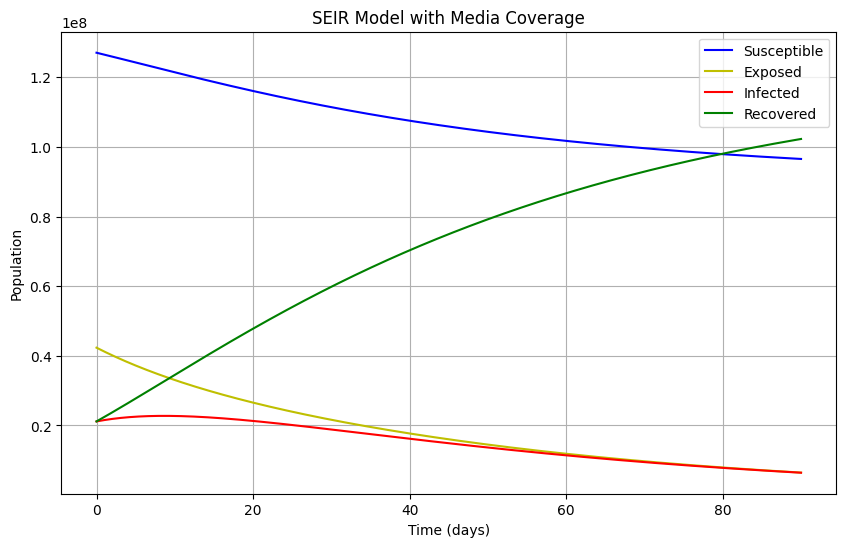

In [4]:
result = odeint(seir_model, y0, t, args=(N, A, beta1, beta2, alpha, mu, k, m))
S, E, I, R = result.T

plt.figure(figsize=(10, 6))
plt.plot(t, S, 'b', label='Susceptible')
plt.plot(t, E, 'y', label='Exposed')
plt.plot(t, I, 'r', label='Infected')
plt.plot(t, R, 'g', label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title('SEIR Model with Media Coverage')
plt.legend()
plt.grid(True)
plt.show()

## Observation
- With beta1 = 0.8, the infection spreads and peaks around day __.
- The Recovered population grows as the Infected population declines.
- This demonstrates the importance of the transmission rate (beta1).

## Results (Day 06)

Using the real parameter values from Ding, Fu, Kang (2021), fitted to Brazil COVID-19 data:

| Parameter | Value |
|-----------|-------|
| β₁ | 0.0933 /day |
| β₂ | 0.05 /day |
| α | 2578.6 |
| k | 0.04 /day |
| m | 0.0599 /day |
| μ | 3.5767 × 10⁻⁵ /day |
| R₀ | 1.55 |

### Observations
- The Infected population peaks around day [X].
- The Recovered population grows steadily after the peak.
- The curve matches the shape of Fig. 4(a) in the paper (blue deterministic line).

### Next Step
Add Lévy noise to this model to reproduce Fig. 4 (green and red stochastic lines).

In [6]:
plt.savefig('seir_paper_params.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved as seir_paper_params.png")

<Figure size 640x480 with 0 Axes>

Plot saved as seir_paper_params.png
